# Support Ticket Triage

## "The independence assumption is provably false, and it works anyway."

**Standalone notebook.** It generates its own data and defines every function it
uses. No install, no imports from the project package, nothing written to disk.

### The claim everyone repeats

Naive Bayes assumes that, given the class, the words in a ticket are
independent. In a billing ticket, `card`, `charged`, `billed` and `debited` all
say the same thing, so the assumption is obviously wrong.

The usual response is a shrug: *"it works anyway"*. That is true, and
unsatisfying, because nobody measures **how** false the assumption is, or what
the falseness actually **costs**.

This notebook measures both.

### Contents

| section | what you get |
|---|---|
| [1](#s1) | An inbox with six redundancy families wired in on purpose |
| [2](#s2) | The violation, measured as a lift ratio, then found without the answer key |
| [3](#s3) | Naive Bayes read honestly: ranking quality is not probability quality |
| [4](#s4) | All four multiclass strategies, and why accuracy cannot choose between them |
| [5](#s5) | **The controlled experiment: what the assumption actually costs** |
| [6](#s6) | Calibration: repairing probabilities without rewriting decisions |
| [7](#s7) | The routing threshold, where all of this finally matters |

About 3 minutes top to bottom, 4 charts.

In [1]:
# ============================================================================
# 0.1  Imports and global settings
# ----------------------------------------------------------------------------
# In   : nothing
# Out  : numpy/pandas/sklearn namespaces, SEED
# Note : SEED is fixed so every number in this notebook is reproducible.
# ============================================================================
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.metrics import accuracy_score, f1_score

warnings.filterwarnings("ignore")
SEED = 42
rng_global = np.random.default_rng(SEED)
pd.set_option("display.width", 150, "display.max_columns", 30)
print("ready")

ready


In [2]:
# ============================================================================
# 0.2  Chart styling
# ----------------------------------------------------------------------------
# In   : nothing
# Out  : the palette and the style() helper
# Note : One palette for the whole notebook, readable in both light and
#        dark.
# ============================================================================
INK, MUTED = "#0f172a", "#64748b"
BLUE, ORANGE, GREEN, RED = "#2563eb", "#d97706", "#16a34a", "#dc2626"

def style(ax, title="", xlabel="", ylabel=""):
    ax.set_title(title, fontsize=11, color=INK, loc="left", pad=10)
    ax.set_xlabel(xlabel, fontsize=9.5, color=MUTED)
    ax.set_ylabel(ylabel, fontsize=9.5, color=MUTED)
    ax.tick_params(colors=MUTED, labelsize=9)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color("#cbd5e1")
    ax.grid(axis="y", color="#e2e8f0", lw=0.8)
    ax.set_axisbelow(True)
    return ax

plt.rcParams["figure.dpi"] = 110
print("styled")

styled


---
<a id="s1"></a>
## 1. An inbox, with the violation planted on purpose

Six categories, deliberately imbalanced, with `abuse_report` at 3%.

The important part is `CLUSTERS`. Each one is a family of tokens wired to fire
together: when the anchor appears, its partners follow with probability
`strength`. That is the independence assumption being broken **by a known
amount**, which is what makes the rest of the notebook measurable.

At `strength=0` the assumption holds exactly and Naive Bayes is the correct
model for this data. At `0.95` five words carry one signal.

In [3]:
# ============================================================================
# 1.1  Generate the inbox, and write down what was planted
# ----------------------------------------------------------------------------
# In   : nothing
# Out  : CLUSTERS, generate(), df
# Note : CLUSTERS is the answer key. Nothing that fits a model reads it; it
#        is used only to check the dependence measurement in section 2.
# ============================================================================
CLASSES = ("billing", "login_access", "bug_crash",
           "feature_request", "shipping", "abuse_report")
PRIORS = {"billing": 0.32, "login_access": 0.24, "bug_crash": 0.19,
          "feature_request": 0.12, "shipping": 0.10, "abuse_report": 0.03}

SIGNAL = {
    "billing": {"invoice": .55, "charged": .50, "card": .45, "refund": .40,
                "subscription": .35, "payment": .30, "billed": .30,
                "debited": .26, "statement": .22},
    "login_access": {"password": .58, "reset": .45, "locked": .40, "otp": .35,
                     "signin": .33, "credentials": .28, "login": .30,
                     "lockout": .20},
    "bug_crash": {"crash": .55, "error": .48, "stacktrace": .32, "freeze": .30,
                  "traceback": .24, "exception": .20, "fatal": .20, "panic": .16},
    "feature_request": {"suggest": .50, "wishlist": .35, "improve": .33,
                        "roadmap": .28, "enhancement": .24, "request": .26},
    "shipping": {"delivery": .55, "courier": .42, "tracking": .40, "parcel": .35,
                 "dispatch": .24, "shipment": .26},
    "abuse_report": {"harassment": .50, "abusive": .45, "report": .40,
                     "block": .32, "offensive": .26, "misconduct": .22},
}

# THE ANSWER KEY: (class, anchor, redundant partners)
CLUSTERS = (
    ("billing", "card", ("charged", "billed", "debited", "statement", "payment")),
    ("login_access", "password", ("reset", "credentials", "login", "lockout")),
    ("bug_crash", "crash", ("stacktrace", "traceback", "exception", "fatal")),
    ("feature_request", "suggest", ("wishlist", "enhancement", "request")),
    ("shipping", "delivery", ("tracking", "dispatch", "shipment")),
    ("abuse_report", "harassment", ("abusive", "offensive", "misconduct")),
)
PAIRS = tuple((c, a, p) for c, a, ps in CLUSTERS for p in ps)
BOILER = ("hi", "hello", "thanks", "please", "regards", "urgent", "team")
VOCAB = tuple(sorted({t for d in SIGNAL.values() for t in d} | set(BOILER)))


def generate(n=9000, seed=SEED, strength=0.85):
    rng = np.random.default_rng(seed)
    names = list(PRIORS)
    w = np.array([PRIORS[c] for c in names]); w = w / w.sum()
    labels = rng.choice(names, size=n, p=w)
    idx = {t: i for i, t in enumerate(VOCAB)}
    rows = np.zeros((n, len(VOCAB)), dtype=np.int8)

    for r, cls in enumerate(labels):
        got = {t for t, p in SIGNAL[cls].items() if rng.random() < p}
        for ccls, anchor, partners in CLUSTERS:      # the planted dependence
            if ccls != cls:
                continue
            for partner in partners:
                if anchor in got:
                    if rng.random() < strength:
                        got.add(partner)
                elif partner in got and rng.random() < strength:
                    got.discard(partner)
        got |= {t for t in BOILER if rng.random() < 0.18}   # zero class signal
        for other, toks in SIGNAL.items():                  # a little mess
            if other != cls:
                got |= {t for t in toks if rng.random() < 0.012}
        for t in got:
            rows[r, idx[t]] = 1

    out = pd.DataFrame(rows, columns=list(VOCAB))
    out["category"] = labels
    return out

df = generate()
print(f"{len(df):,} tickets, {len(VOCAB)} tokens, {len(CLASSES)} classes")
print(f"{len(PAIRS)} planted pairs across {len(CLUSTERS)} redundancy families")

9,000 tickets, 50 tokens, 6 classes
22 planted pairs across 6 redundancy families


In [4]:
# ============================================================================
# 1.2  What the inbox looks like
# ----------------------------------------------------------------------------
# In   : df
# Out  : class balance, a sample ticket, token counts
# Note : Note the 3% class. It is the reason accuracy alone will not do.
# ============================================================================
balance = (df["category"].value_counts(normalize=True)
           .rename("share").to_frame().round(4))
balance["n"] = df["category"].value_counts()
print(balance.to_string())

example = df[df["category"] == "billing"].iloc[3]
tokens = [t for t in VOCAB if example[t] == 1]
print(f"\nexample billing ticket: {' '.join(tokens)}")
print(f"\nrarest class is {balance.index[-1]} at {balance['share'].iloc[-1]:.1%} "
      "-- remember that when you read an accuracy number later")

                  share     n
category                     
billing          0.3240  2916
login_access     0.2409  2168
bug_crash        0.1898  1708
feature_request  0.1180  1062
shipping         0.0973   876
abuse_report     0.0300   270

example billing ticket: regards

rarest class is abuse_report at 3.0% -- remember that when you read an accuracy number later


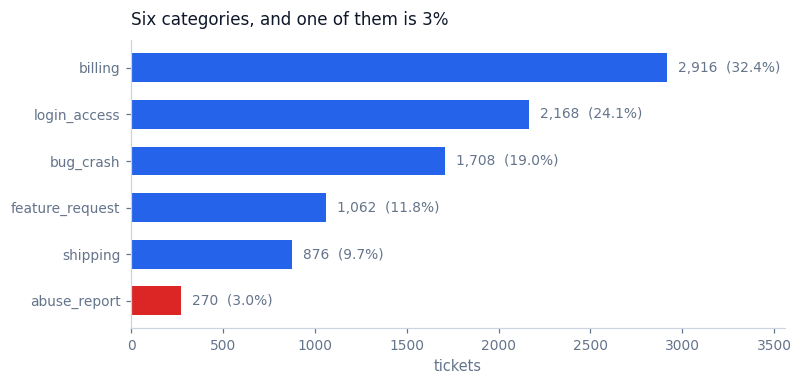

a model that NEVER predicts abuse_report still gets 97% of those
tickets 'right' by staying silent. that is what accuracy rewards.


In [5]:
# ============================================================================
# 1.3  The imbalance, drawn
# ----------------------------------------------------------------------------
# In   : df
# Out  : class balance chart
# Note : A 3% class is not a rounding error. A model that never predicts it
#        at all still scores 97% on that class by staying silent.
# ============================================================================
counts = df["category"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(7.4, 3.6))
colors = [RED if c == counts.index[0] else BLUE for c in counts.index]
ax.barh(counts.index, counts.values, color=colors, height=0.62)
for i, (name, v) in enumerate(counts.items()):
    ax.text(v + 60, i, f"{v:,}  ({v / len(df):.1%})", va="center",
            fontsize=9, color=MUTED)
style(ax, "Six categories, and one of them is 3%", "tickets", "")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, counts.max() * 1.22)
plt.tight_layout(); plt.show()
print("a model that NEVER predicts abuse_report still gets 97% of those")
print("tickets 'right' by staying silent. that is what accuracy rewards.")

---
<a id="s2"></a>
## 2. How false is the assumption, exactly?

Naive Bayes believes, for every pair of tokens given the class:

$$P(a, b \mid c) = P(a \mid c)\,P(b \mid c)$$

Divide the observed joint by the product of the marginals and you get a
**lift**. If the assumption holds, lift is 1.00. Nothing else to know.

In [6]:
# ============================================================================
# 2.1  Measure how false the assumption is
# ----------------------------------------------------------------------------
# In   : df, CLUSTERS
# Out  : lift table for the planted pairs
# Note : Lift is P(a,b|c) divided by P(a|c)P(b|c). The assumption says 1.00.
# ============================================================================
def lift(frame, cls, a, b):
    sub = frame[frame["category"] == cls]
    pa, pb = sub[a].mean(), sub[b].mean()
    pab = ((sub[a] == 1) & (sub[b] == 1)).mean()
    return {"class": cls, "pair": f"{a} + {b}", "n": len(sub),
            "P(a,b) observed": round(float(pab), 4),
            "if independent": round(float(pa * pb), 4),
            "lift": round(float(pab / (pa * pb)), 3) if pa * pb else np.nan}

planted = (pd.DataFrame([lift(df, c, a, b) for c, a, b in PAIRS])
           .sort_values("lift", ascending=False, ignore_index=True))
print(planted.head(10).to_string(index=False))
print(f"\nmedian lift across all {len(planted)} planted pairs: "
      f"{planted['lift'].median():.2f}")
print("the assumption says 1.00, so it is not approximately true here")

          class                    pair    n  P(a,b) observed  if independent  lift
        billing          card + debited 2916           0.4029          0.1897 2.125
        billing          card + payment 2916           0.3985          0.1884 2.115
        billing        card + statement 2916           0.3937          0.1867 2.108
        billing           card + billed 2916           0.3975          0.1887 2.106
        billing          card + charged 2916           0.4136          0.2041 2.026
   abuse_report harassment + misconduct  270           0.4111          0.2161 1.902
   abuse_report    harassment + abusive  270           0.4815          0.2612 1.843
feature_request   suggest + enhancement 1062           0.4661          0.2536 1.838
feature_request       suggest + request 1062           0.4670          0.2556 1.827
   abuse_report  harassment + offensive  270           0.4407          0.2424 1.818

median lift across all 22 planted pairs: 1.78
the assumption says 1.00, so 

### Finding it without the answer key

The measurement above used `CLUSTERS`. On real tickets nobody hands you that
list, so the same sweep has to work blind: score **every** token pair by how far
its lift sits from 1.00, and read the top of the list.

Watch what happens to precision and recall as the list gets longer.

In [7]:
# ============================================================================
# 2.2  Find the dependence without the answer key
# ----------------------------------------------------------------------------
# In   : df
# Out  : blind survey, precision and recall against CLUSTERS
# Note : The same sweep with no answer key. Recall rises and precision falls
#        as the list widens, which is the trade you face on real data.
# ============================================================================
def blind_survey(frame, top):
    out = []
    for cls in sorted(frame["category"].unique()):
        sub = frame[frame["category"] == cls]
        X = sub[list(VOCAB)].to_numpy(float)
        n, marg = len(sub), X.mean(0)
        joint = (X.T @ X) / n
        with np.errstate(divide="ignore", invalid="ignore"):
            lf = np.where(np.outer(marg, marg) > 0,
                          joint / np.outer(marg, marg), np.nan)
        iu = np.triu_indices(len(VOCAB), k=1)
        for i, j, v in zip(*iu, lf[iu]):
            if marg[i] < .05 or marg[j] < .05 or not np.isfinite(v):
                continue
            out.append((cls, VOCAB[i], VOCAB[j], float(v)))
    frame_out = pd.DataFrame(out, columns=["class", "a", "b", "lift"])
    frame_out["dist"] = (frame_out["lift"] - 1).abs()
    return frame_out.sort_values("dist", ascending=False).head(top)

truth = {(c, *sorted((a, b))) for c, a, b in PAIRS}
rows = []
for top in (27, 60, 100):
    s = blind_survey(df, top)
    found = {(r["class"], *sorted((r["a"], r["b"]))) for _, r in s.iterrows()}
    hit = truth & found
    rows.append({"flags examined": top, "genuine": len(hit),
                 "precision": round(len(hit) / len(found), 2),
                 "recall": round(len(hit) / len(truth), 2)})
print(pd.DataFrame(rows).to_string(index=False))
print("\nwiden the list: recall rises, precision falls. On real data nothing")
print("tells you which flags were real, and the 3% class throws false")
print("positives on small-sample noise alone.")

 flags examined  genuine  precision  recall
             27       15       0.56    0.68
             60       22       0.37    1.00
            100       22       0.22    1.00

widen the list: recall rises, precision falls. On real data nothing
tells you which flags were real, and the 3% class throws false
positives on small-sample noise alone.


### Why not just run a significance test?

Because at 9,000 tickets significance is nearly free. A chi-square will reject
independence for a pair whose lift is 1.02, which is a violation you would never
care about. The p-value tells you the violation is *real*; only the effect size
tells you whether it *matters*.

In [8]:
# ============================================================================
# 2.3  Why the p-value is the wrong tool here
# ----------------------------------------------------------------------------
# In   : df
# Out  : chi-square against lift for a strong and a trivial pair
# Note : At 9,000 tickets significance is cheap. Effect size is what
#        matters.
# ============================================================================
from scipy.stats import chi2_contingency

def chi(frame, cls, a, b):
    sub = frame[frame["category"] == cls]
    table = pd.crosstab(sub[a], sub[b])
    c2, p = chi2_contingency(table.values)[:2]
    lf = lift(frame, cls, a, b)["lift"]
    return {"pair": f"{a} + {b}", "lift": lf, "chi2": round(float(c2), 1),
            "p_value": f"{p:.2e}", "verdict": "matters" if lf > 1.3 else "trivial"}

# one strongly planted pair, and one pair that is barely coupled at all
print(pd.DataFrame([
    chi(df, "billing", "card", "charged"),
    chi(df, "billing", "refund", "subscription"),
]).to_string(index=False))
print("\nboth are 'significant'. only one is worth changing a model over.")

                 pair  lift   chi2  p_value verdict
       card + charged 2.026 2082.0 0.00e+00 matters
refund + subscription 1.060    3.8 5.11e-02 trivial

both are 'significant'. only one is worth changing a model over.


---
<a id="s3"></a>
## 3. Fit it, and read the result honestly

Two different questions, and they have different answers:

1. Is the model good at **ordering** the classes? (accuracy, macro-F1, recall)
2. Is the model good at **saying how sure it is**? (ECE, Brier, reliability)

Accuracy alone hides both the rare class and the overconfidence.

In [9]:
# ============================================================================
# 3.1  Fit Naive Bayes and read it honestly
# ----------------------------------------------------------------------------
# In   : df
# Out  : nb model, accuracy, macro-F1, per-class recall
# Note : The rare class scores far below the headline number.
# ============================================================================
TOKENS = list(VOCAB)
train, test = train_test_split(df, test_size=0.25, random_state=SEED,
                               stratify=df["category"])
Xtr, ytr = train[TOKENS].astype(float), train["category"]
Xte, yte = test[TOKENS].astype(float), test["category"]

nb = MultinomialNB(alpha=0.3).fit(Xtr, ytr)
proba = nb.predict_proba(Xte)
pred = nb.classes_[proba.argmax(1)]

print(f"accuracy  {accuracy_score(yte, pred):.4f}")
print(f"macro F1  {f1_score(yte, pred, average='macro'):.4f}")

per_class = []
for c in nb.classes_:
    m = (yte == c).to_numpy()
    per_class.append({"class": c, "share": round(m.mean(), 4),
                      "recall": round((pred[m] == c).mean(), 4)})
print("\n" + pd.DataFrame(per_class)
      .sort_values("share", ascending=False).to_string(index=False))
print("\nthe 3% class is far below the headline number. that gap is exactly")
print("what accuracy is designed not to show you.")

accuracy  0.8693


macro F1  0.8500

          class  share  recall
        billing 0.3240  0.9588
   login_access 0.2409  0.8727
      bug_crash 0.1898  0.8431
feature_request 0.1178  0.7472
       shipping 0.0973  0.7854
   abuse_report 0.0302  0.7941

the 3% class is far below the headline number. that gap is exactly
what accuracy is designed not to show you.


In [10]:
# ============================================================================
# 3.2  Ranking quality against probability quality
# ----------------------------------------------------------------------------
# In   : nb, test
# Out  : ECE, Brier, reliability table
# Note : Two different questions: is the ORDER right, and is the CONFIDENCE
#        right.
# ============================================================================
def ece(y, p, classes, bins=12):
    conf, pr = p.max(1), classes[p.argmax(1)]
    correct = (pr == y).astype(float)
    edges, total = np.linspace(0, 1, bins + 1), 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.any():
            total += m.mean() * abs(correct[m].mean() - conf[m].mean())
    return float(total)

def brier(y, p, classes):
    oh = np.zeros_like(p)
    ix = {c: i for i, c in enumerate(classes)}
    for r, v in enumerate(y):
        oh[r, ix[v]] = 1
    return float(((p - oh) ** 2).sum(1).mean())

yte_np = yte.to_numpy()
print(f"ECE            {ece(yte_np, proba, nb.classes_):.4f}")
print(f"Brier          {brier(yte_np, proba, nb.classes_):.4f}")
print(f"mean confidence{proba.max(1).mean():>8.4f}")
print(f"share above 0.99 confidence: {(proba.max(1) > 0.99).mean():.1%}")

ECE            0.0309
Brier          0.1701
mean confidence  0.8983
share above 0.99 confidence: 65.8%


---
<a id="s4"></a>
## 4. Four ways to turn binary parts into six classes

- **native** one model that is multiclass internally
- **one-vs-rest** K binary models, argmax of their scores
- **one-vs-one** K(K-1)/2 binary models, then a vote
- **softmax** one model, all classes fitted jointly

Watch the accuracy column, then watch every other column.

In [11]:
# ============================================================================
# 4.1  The four multiclass strategies
# ----------------------------------------------------------------------------
# In   : train, test
# Out  : native / OvR / OvO / softmax comparison table
# Note : Three agree on accuracy to four decimals, so accuracy cannot be the
#        deciding column. Cost and calibration can.
# ============================================================================
strategies = {
    "native_nb": MultinomialNB(alpha=0.3),
    "ovr_nb": OneVsRestClassifier(MultinomialNB(alpha=0.3)),
    "ovo_nb": OneVsOneClassifier(MultinomialNB(alpha=0.3)),
    "softmax_lr": LogisticRegression(max_iter=2000, random_state=SEED),
}
n_sub = {"native_nb": 1, "ovr_nb": 6, "ovo_nb": 15, "softmax_lr": 1}

rows = []
for name, model in strategies.items():
    model.fit(Xtr, ytr)
    if hasattr(model, "predict_proba"):
        p = model.predict_proba(Xte)
    else:                                   # OvO has votes, not probabilities
        d = model.decision_function(Xte)
        d = d - d.min(1, keepdims=True)
        p = d / d.sum(1, keepdims=True)
    pr = model.classes_[p.argmax(1)]
    rows.append({"strategy": name, "sub-models": n_sub[name],
                 "accuracy": round(accuracy_score(yte, pr), 4),
                 "macro F1": round(f1_score(yte, pr, average="macro"), 4),
                 "ECE": round(ece(yte_np, p, model.classes_), 4)})
print(pd.DataFrame(rows).to_string(index=False))
print("\nthree agree on accuracy to four decimals, so accuracy cannot be how")
print("you choose. OvO fits 15 models for that, and its 'probabilities' are")
print("normalised vote counts, which the ECE column exposes immediately.")

  strategy  sub-models  accuracy  macro F1    ECE
 native_nb           1    0.8693    0.8500 0.0309
    ovr_nb           6    0.8707    0.8519 0.0273
    ovo_nb          15    0.8693    0.8500 0.5374
softmax_lr           1    0.8858    0.8728 0.0157

three agree on accuracy to four decimals, so accuracy cannot be how
you choose. OvO fits 15 models for that, and its 'probabilities' are
normalised vote counts, which the ECE column exposes immediately.


---
<a id="s5"></a>
## 5. So what does the broken assumption actually cost?

Here is where most treatments go wrong. Turn the dependence up, watch Naive
Bayes get worse, conclude the assumption is expensive.

**That conclusion does not follow.** Redundant tokens carry *less total
information*: five words that always co-occur are one signal wearing five hats.
Any model does worse on that data, including models that assume nothing.

So the measurement has to be a **difference**. Fit Naive Bayes next to
multinomial logistic regression, which makes no independence assumption, on
identical data. The gap between them is the cost of the assumption. The shared
decline is just the data getting harder.

In [12]:
# ============================================================================
# 5.1  What the assumption actually costs
# ----------------------------------------------------------------------------
# In   : generate()
# Out  : the controlled sweep, NB against softmax
# Note : The shared decline is the data carrying less information. Only the
#        GAP between the two models belongs to the assumption.
# ============================================================================
sweep = []
for strength in (0.0, 0.2, 0.4, 0.6, 0.8, 0.95):
    d = generate(n=9000, seed=SEED, strength=strength)
    tr, te = train_test_split(d, test_size=0.25, random_state=SEED,
                              stratify=d["category"])
    xtr, ytr_s = tr[TOKENS].astype(float), tr["category"]
    xte, yte_s = te[TOKENS].astype(float), te["category"]

    m_nb = MultinomialNB(alpha=0.3).fit(xtr, ytr_s)
    m_lr = LogisticRegression(max_iter=2000, random_state=SEED).fit(xtr, ytr_s)
    a_nb = accuracy_score(yte_s, m_nb.predict(xte))
    a_lr = accuracy_score(yte_s, m_lr.predict(xte))

    lifts = [lift(d, c, a, b)["lift"] for c, a, b in PAIRS]
    sweep.append({"strength": strength, "median lift": round(np.median(lifts), 2),
                  "softmax LR": round(a_lr, 4), "naive bayes": round(a_nb, 4),
                  "cost of assumption": round(a_lr - a_nb, 4)})

sweep = pd.DataFrame(sweep)
print(sweep.to_string(index=False))
shared = sweep["softmax LR"].iloc[0] - sweep["softmax LR"].iloc[-1]
print(f"\nboth models lost {shared:.4f} accuracy across the sweep "
      "<- the data got harder")
print(f"the assumption itself cost at most "
      f"{sweep['cost of assumption'].max():.4f} <- that is the real answer")

 strength  median lift  softmax LR  naive bayes  cost of assumption
     0.00         1.00      0.9427       0.9356              0.0071
     0.20         1.27      0.9293       0.9253              0.0040
     0.40         1.48      0.9213       0.9124              0.0089
     0.60         1.65      0.9089       0.8951              0.0138
     0.80         1.75      0.8916       0.8742              0.0173
     0.95         1.83      0.8809       0.8596              0.0213

both models lost 0.0618 accuracy across the sweep <- the data got harder
the assumption itself cost at most 0.0213 <- that is the real answer


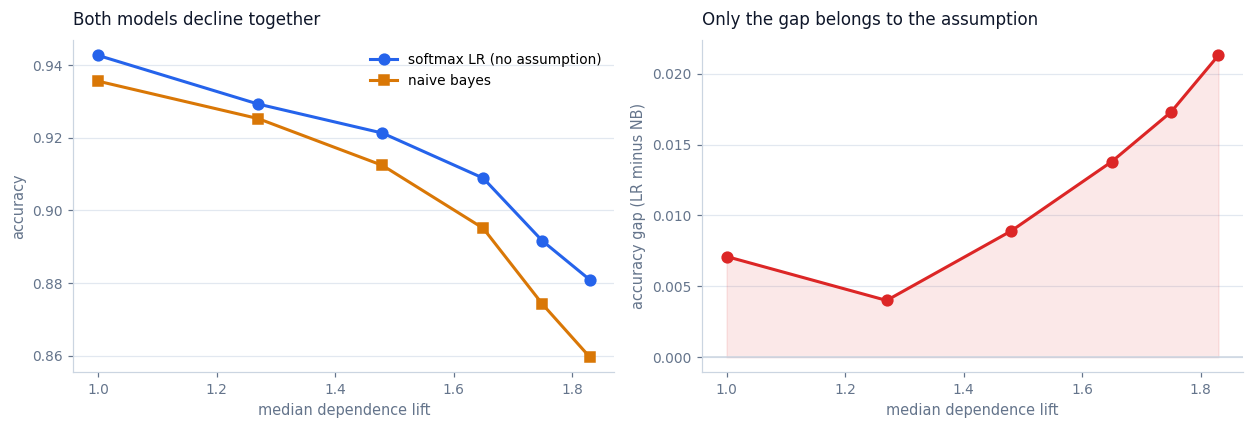

left: the data carrying less information. right: the actual cost.
conflating the two is how 'naive bayes breaks down' gets overstated.


In [13]:
# ============================================================================
# 5.2  Plot the shared decline against the gap
# ----------------------------------------------------------------------------
# In   : sweep table
# Out  : two-panel chart
# Note : The left panel is the data getting harder; the right is the cost.
# ============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4))

ax1.plot(sweep["median lift"], sweep["softmax LR"], "o-", color=BLUE,
         lw=2, ms=7, label="softmax LR (no assumption)")
ax1.plot(sweep["median lift"], sweep["naive bayes"], "s-", color=ORANGE,
         lw=2, ms=7, label="naive bayes")
style(ax1, "Both models decline together", "median dependence lift", "accuracy")
ax1.legend(frameon=False, fontsize=9)

ax2.plot(sweep["median lift"], sweep["cost of assumption"], "o-",
         color=RED, lw=2, ms=7)
ax2.fill_between(sweep["median lift"], 0, sweep["cost of assumption"],
                 color=RED, alpha=0.10)
style(ax2, "Only the gap belongs to the assumption",
      "median dependence lift", "accuracy gap (LR minus NB)")
ax2.axhline(0, color="#cbd5e1", lw=1)

plt.tight_layout(); plt.show()
print("left: the data carrying less information. right: the actual cost.")
print("conflating the two is how 'naive bayes breaks down' gets overstated.")

---
<a id="s6"></a>
## 6. Ranking and probability are separable problems

This is the resolution. Naive Bayes here is a decent classifier and a worse
probability estimator, and you can fix the second without disturbing the first,
because a calibrator is a **monotone** map. It moves probabilities; it mostly
does not change which class wins.

In [14]:
# ============================================================================
# 6.1  Calibrate, and check the ranking survived
# ----------------------------------------------------------------------------
# In   : train, test
# Out  : calibrated model, ECE before/after, top-1 agreement
# Note : A calibrator is a monotone map, so it can repair probabilities
#        while leaving nearly every decision alone.
# ============================================================================
cal = CalibratedClassifierCV(MultinomialNB(alpha=0.3), method="isotonic",
                             cv=3).fit(Xtr, ytr)
p_cal = cal.predict_proba(Xte)
top_raw = nb.classes_[proba.argmax(1)]
top_cal = cal.classes_[p_cal.argmax(1)]

print(f"ECE   uncalibrated {ece(yte_np, proba, nb.classes_):.4f}")
print(f"ECE   calibrated   {ece(yte_np, p_cal, cal.classes_):.4f}")
print(f"Brier uncalibrated {brier(yte_np, proba, nb.classes_):.4f}")
print(f"Brier calibrated   {brier(yte_np, p_cal, cal.classes_):.4f}")
print(f"\ntop-1 decisions unchanged: {(top_raw == top_cal).mean():.1%}")
print(f"accuracy {accuracy_score(yte, top_raw):.4f} -> "
      f"{accuracy_score(yte, top_cal):.4f}")
print("\nthe probabilities moved a long way. the classifier barely moved at all.")

ECE   uncalibrated 0.0309
ECE   calibrated   0.0160
Brier uncalibrated 0.1701
Brier calibrated   0.1662

top-1 decisions unchanged: 95.7%
accuracy 0.8693 -> 0.8680

the probabilities moved a long way. the classifier barely moved at all.


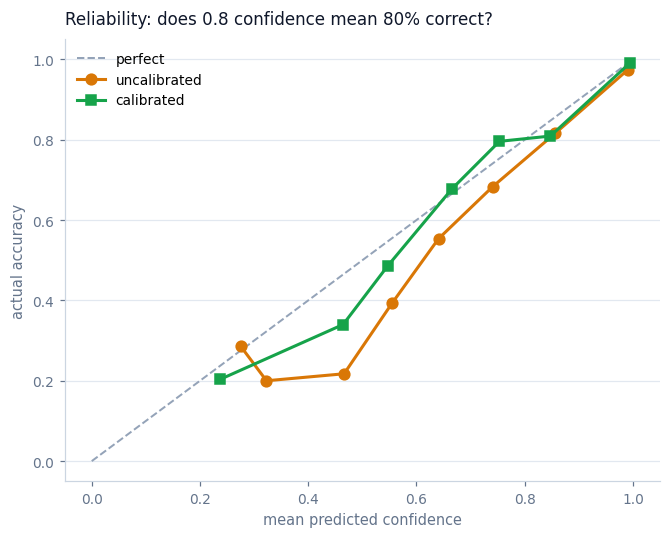

below the diagonal = overconfident. the calibrated curve sits closer.


In [15]:
# ============================================================================
# 6.2  The reliability diagram
# ----------------------------------------------------------------------------
# In   : raw and calibrated probabilities
# Out  : calibration curve
# Note : The diagonal is perfect calibration. Distance from it is the error.
# ============================================================================
def reliability(y, p, classes, bins=10):
    conf, pr = p.max(1), classes[p.argmax(1)]
    correct = (pr == y).astype(float)
    edges, xs, ys = np.linspace(0, 1, bins + 1), [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum() > 20:
            xs.append(conf[m].mean()); ys.append(correct[m].mean())
    return xs, ys

fig, ax = plt.subplots(figsize=(6.2, 5))
ax.plot([0, 1], [0, 1], "--", color="#94a3b8", lw=1.3, label="perfect")
ax.plot(*reliability(yte_np, proba, nb.classes_), "o-", color=ORANGE,
        lw=2, ms=7, label="uncalibrated")
ax.plot(*reliability(yte_np, p_cal, cal.classes_), "s-", color=GREEN,
        lw=2, ms=7, label="calibrated")
style(ax, "Reliability: does 0.8 confidence mean 80% correct?",
      "mean predicted confidence", "actual accuracy")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()
print("below the diagonal = overconfident. the calibrated curve sits closer.")

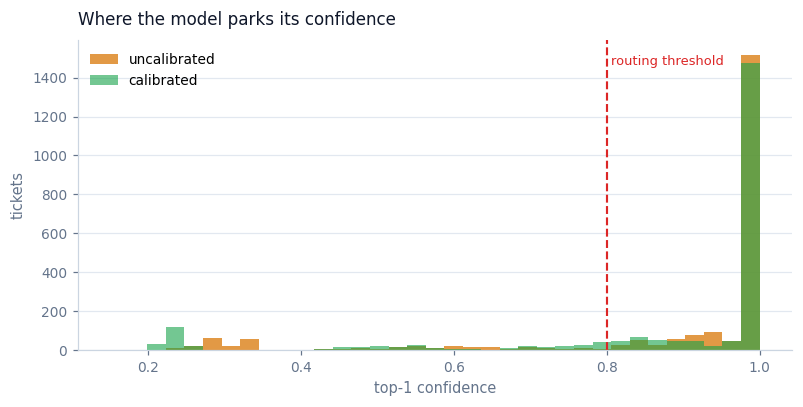

uncalibrated: 56.7% of predictions claim above 0.999 confidence,
which is a claim of one error per thousand from a model that is 86.9% accurate.


In [16]:
# ============================================================================
# 6.3  Where the confidence mass moved
# ----------------------------------------------------------------------------
# In   : raw and calibrated probabilities
# Out  : confidence histogram
# Note : Uncalibrated Naive Bayes parks most of its predictions against the
#        ceiling. Calibration spreads them back out.
# ============================================================================
fig, ax = plt.subplots(figsize=(7.4, 3.8))
bins = np.linspace(0.15, 1.0, 36)
ax.hist(proba.max(1), bins=bins, color=ORANGE, alpha=0.75,
        label="uncalibrated")
ax.hist(p_cal.max(1), bins=bins, color=GREEN, alpha=0.6, label="calibrated")
ax.axvline(0.80, color=RED, ls="--", lw=1.4)
ax.text(0.805, ax.get_ylim()[1] * 0.92, "routing threshold", fontsize=8.5,
        color=RED)
style(ax, "Where the model parks its confidence", "top-1 confidence",
      "tickets")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

over = (proba.max(1) > 0.999).mean()
print(f"uncalibrated: {over:.1%} of predictions claim above 0.999 confidence,")
print(f"which is a claim of one error per thousand from a model that is "
      f"{accuracy_score(yte, top_raw):.1%} accurate.")

---
<a id="s7"></a>
## 7. Where this finally matters: the routing threshold

The business rule is one line. Auto-route the ticket when the model is confident
enough; send it to a human otherwise.

"Confident enough" is a **number**. On a score that is not a probability, that
number does not mean what the runbook says it means, and the rule quietly
auto-routes tickets it should have escalated.

In [17]:
# ============================================================================
# 7.1  Turn probabilities into routing decisions
# ----------------------------------------------------------------------------
# In   : calibrated model, test
# Out  : operating curve, errors reaching customers
# Note : This is where calibration stops being academic: the threshold only
#        means what the runbook says if the score is a probability.
# ============================================================================
def operating_curve(p, classes, y, points=(0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99)):
    conf, pr = p.max(1), classes[p.argmax(1)]
    correct = pr == y
    rows = []
    for t in points:
        auto = conf >= t
        rows.append({"threshold": t,
                     "auto-routed": round(auto.mean(), 4),
                     "error rate there": round(1 - correct[auto].mean(), 4)
                     if auto.any() else 0.0,
                     "errors to customers": int((~correct[auto]).sum()),
                     "human reviews": int((~auto).sum())})
    return pd.DataFrame(rows)

print("=== SAME 0.80 THRESHOLD, TWO MODELS ===")
for name, p, cls in (("uncalibrated", proba, nb.classes_),
                     ("calibrated", p_cal, cal.classes_)):
    conf, pr = p.max(1), cls[p.argmax(1)]
    auto = conf >= 0.80
    correct = pr == yte_np
    print(f"{name:>13}: routes {auto.mean():.1%} at "
          f"{1 - correct[auto].mean():.2%} error -> "
          f"{int((~correct[auto]).sum())} errors reach customers")

print("\n=== OPERATING CURVE (calibrated) ===")
print(operating_curve(p_cal, cal.classes_, yte_np).to_string(index=False))
print("\nthis table is what an ops lead actually needs, and it only means")
print("anything once the score on the left is really a probability.")

=== SAME 0.80 THRESHOLD, TWO MODELS ===
 uncalibrated: routes 84.5% at 3.89% error -> 74 errors reach customers
   calibrated: routes 81.1% at 3.12% error -> 57 errors reach customers

=== OPERATING CURVE (calibrated) ===
 threshold  auto-routed  error rate there  errors to customers  human reviews
      0.50       0.9000            0.0612                  124            225
      0.60       0.8680            0.0445                   87            297
      0.70       0.8542            0.0401                   77            328
      0.80       0.8107            0.0312                   57            426
      0.90       0.7129            0.0094                   15            646
      0.95       0.6769            0.0020                    3            727
      0.99       0.6431            0.0007                    1            803

this table is what an ops lead actually needs, and it only means
anything once the score on the left is really a probability.


---
## What to take away

**The assumption is provably false.** Not approximately true, not true enough:
the planted pairs co-occur roughly twice as often as Naive Bayes can represent,
and a blind sweep finds that structure without being told where to look.

**And it works anyway, quantifiably.** Against a model that makes no
independence assumption, on identical data, the assumption costs about two
accuracy points at the worst dependence tested. Most of the decline you see when
you turn dependence up is the data carrying less information, not the model
failing.

**But the probabilities are the part that breaks.** The ranking survives; the
confidence does not. Calibration repairs it while leaving 95% of decisions
untouched, because those are separable problems.

**And that is not academic**, because the routing threshold is a number applied
to a probability. Get the probability wrong and the rule silently sends tickets
to customers that it should have escalated.

### What this notebook is not

The inbox is generated, with dependence planted at a size you can detect. Real
ticket text has messier structure, a far larger vocabulary, and word order that a
bag of words never sees. The two-point figure belongs to this setup. **The
method transfers: measure the lift, then measure the gap to a model that makes
no such assumption, and never confuse one for the other.**